In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [6]:
data = pd.read_csv("detect_dataset.csv")

In [7]:
data

,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431,NaN,NaN
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202,NaN,NaN
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251,NaN,NaN
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963,NaN,NaN
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050,NaN,NaN
...,...,...,...,...,...,...,...,...,...
11996,0,-66.237921,38.457041,24.912239,0.094421,-0.552019,0.457598,NaN,NaN
11997,0,-65.849493,37.465454,25.515675,0.103778,-0.555186,0.451407,NaN,NaN
11998,0,-65.446698,36.472055,26.106554,0.113107,-0.558211,0.445104,NaN,NaN
11999,0,-65.029633,35.477088,26.684731,0.122404,-0.561094,0.438690,NaN,NaN


In [14]:
print(data.columns)

Index(['Output (S)', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc', 'Unnamed: 7',
       'Unnamed: 8'],
      dtype='object')


In [15]:
# Remove unwanted extra spaces in column names
data.columns = data.columns.str.strip()

# Remove unnecessary empty columns
data = data.drop(['Unnamed: 7', 'Unnamed: 8'], axis=1)

# Define target column
target_column = 'Output (S)'

# Separate input and output
X = data.drop(target_column, axis=1)
y = data[target_column]

In [16]:
data

,Output (S),Ia,Ib,Ic,Va,Vb,Vc
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050
...,...,...,...,...,...,...,...
11996,0,-66.237921,38.457041,24.912239,0.094421,-0.552019,0.457598
11997,0,-65.849493,37.465454,25.515675,0.103778,-0.555186,0.451407
11998,0,-65.446698,36.472055,26.106554,0.113107,-0.558211,0.445104
11999,0,-65.029633,35.477088,26.684731,0.122404,-0.561094,0.438690


In [8]:
print("First 5 rows of dataset:")
print(data.head())

First 5 rows of dataset:
   Output (S)          Ia        Ib          Ic        Va        Vb        Vc  \
0           0 -170.472196  9.219613  161.252583  0.054490 -0.659921  0.605431   
1           0 -122.235754  6.168667  116.067087  0.102000 -0.628612  0.526202   
2           0  -90.161474  3.813632   86.347841  0.141026 -0.605277  0.464251   
3           0  -79.904916  2.398803   77.506112  0.156272 -0.602235  0.445963   
4           0  -63.885255  0.590667   63.294587  0.180451 -0.591501  0.411050   

   Unnamed: 7  Unnamed: 8  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4         NaN         NaN  


In [9]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
Output (S)        0
Ia                0
Ib                0
Ic                0
Va                0
Vb                0
Vc                0
Unnamed: 7    12001
Unnamed: 8    12001
dtype: int64


In [24]:
print("\nInput Features:")
print(X.head())


Input Features:
           Ia        Ib          Ic        Va        Vb        Vc
0 -170.472196  9.219613  161.252583  0.054490 -0.659921  0.605431
1 -122.235754  6.168667  116.067087  0.102000 -0.628612  0.526202
2  -90.161474  3.813632   86.347841  0.141026 -0.605277  0.464251
3  -79.904916  2.398803   77.506112  0.156272 -0.602235  0.445963
4  -63.885255  0.590667   63.294587  0.180451 -0.591501  0.411050


In [25]:
print("\nTarget Output:")
print(y.head())




Target Output:
0    0
1    0
2    0
3    0
4    0
Name: Output (S), dtype: int64


In [17]:
X = data.drop("Output (S)", axis=1)  
y = data["Output (S)"]

In [18]:
X

,Ia,Ib,Ic,Va,Vb,Vc
0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431
1,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202
2,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251
3,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963
4,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050
...,...,...,...,...,...,...
11996,-66.237921,38.457041,24.912239,0.094421,-0.552019,0.457598
11997,-65.849493,37.465454,25.515675,0.103778,-0.555186,0.451407
11998,-65.446698,36.472055,26.106554,0.113107,-0.558211,0.445104
11999,-65.029633,35.477088,26.684731,0.122404,-0.561094,0.438690


In [19]:
y

0        0
1        0
2        0
3        0
4        0
        ..
11996    0
11997    0
11998    0
11999    0
12000    0
Name: Output (S), Length: 12001, dtype: int64

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [26]:
print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)


Training Data Size: (9600, 6)
Testing Data Size: (2401, 6)


In [27]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [28]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
model.fit(X_train, y_train)
print("\nModel Training Completed ✅")


Model Training Completed ✅


In [31]:
y_pred = model.predict(X_test)

In [32]:
print("\nPredicted Output:")
print(y_pred[:10])


Predicted Output:
[0 1 0 0 0 1 0 0 1 1]


In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy * 100, "%")



Model Accuracy: 99.75010412328197 %


In [34]:
cm = confusion_matrix(y_test, y_pred)

In [35]:
cm

array([[1302,    4],
       [   2, 1093]])

In [36]:
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[1302    4]
 [   2 1093]]


In [37]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1306
           1       1.00      1.00      1.00      1095

    accuracy                           1.00      2401
   macro avg       1.00      1.00      1.00      2401
weighted avg       1.00      1.00      1.00      2401



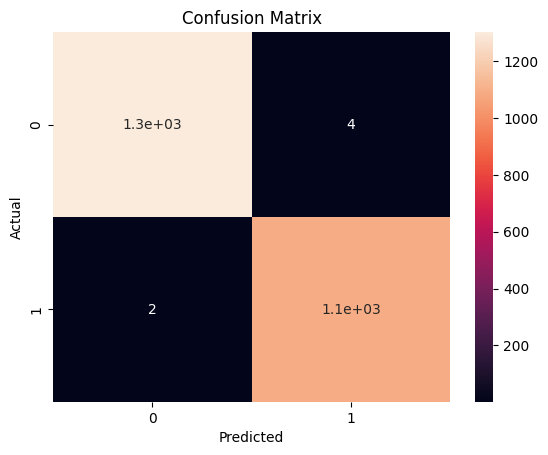

In [38]:
plt.figure()
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
import pickle

# Save trained model
with open("fault_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully ✅")

Model saved successfully ✅


In [40]:
import os
print(os.getcwd())

c:\documents\transmission lines
